In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sklearn.base
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve, average_precision_score
)
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


In [2]:
# 1. Defina a arquitetura exata do modelo PyTorch que você treinou
class EmbeddingClassifier(nn.Module):
    def __init__(self, input_dim=1024):
        super(EmbeddingClassifier, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

# 2. Defina o Wrapper para compatibilidade com Sklearn
class PyTorchClassifierWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model_pytorch):
        self.model_pytorch = model_pytorch
        self.classes_ = np.array([0, 1])
        self._estimator_type = "classifier"

    def fit(self, X, y=None):
        return self

    def predict_proba(self, X):
        self.model_pytorch.eval()
        device = next(self.model_pytorch.parameters()).device
        X_t = torch.as_tensor(X, dtype=torch.float32).to(device)
        with torch.no_grad():
            logits = self.model_pytorch(X_t)
            if len(logits.shape) == 1:
                logits = logits.unsqueeze(1)
            if logits.shape[1] == 1:
                probs = torch.sigmoid(logits).cpu().numpy()
                return np.hstack([1 - probs, probs])
            else:
                return torch.softmax(logits, dim=1).cpu().numpy()

    def predict(self, X):
        # Usamos o predict_proba interno para garantir consistência
        return np.argmax(self.predict_proba(X), axis=1)

In [3]:
# Patch para evitar erro do Sklearn 1.6
def is_classifier_patch(estimator): return True
sklearn.base.is_classifier = is_classifier_patch

try:
    # Carregar dados
    Z_test = np.load("../artifacts/data/Z_test.npy")
    y_test = np.load("../artifacts/data/y_test.npy")
    
    # Carregar modelo calibrado
    modelo_final = joblib.load("../artifacts/models/ids_calibrado_final.pkl")
    print("✅ Modelo e dados carregados com sucesso!")
except Exception as e:
    print(f"❌ Erro ao carregar: {e}")

✅ Modelo e dados carregados com sucesso!


💡 Threshold Otimizado: 0.5363


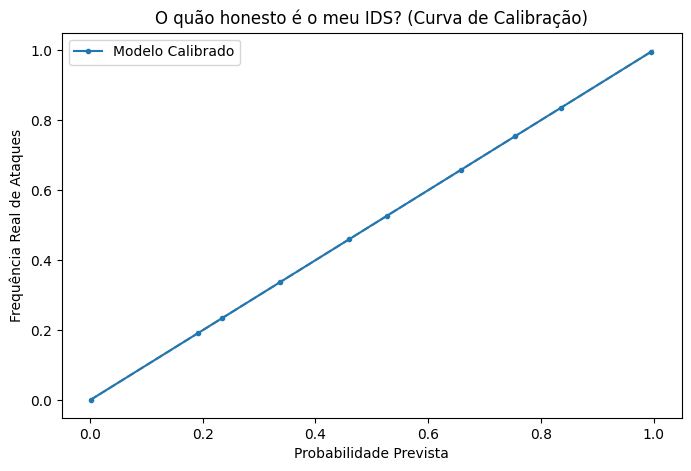

In [4]:
# Obter probabilidades
probs = modelo_final.predict_proba(Z_test)[:, 1]

# Encontrar melhor threshold via G-Mean
fpr, tpr, thresholds = roc_curve(y_test, probs)
gmeans = np.sqrt(tpr * (1 - fpr))
best_threshold = thresholds[np.argmax(gmeans)]

print(f"💡 Threshold Otimizado: {best_threshold:.4f}")

# Plotar Curva de Calibração
fop, mpv = calibration_curve(y_test, probs, n_bins=10)
plt.figure(figsize=(8, 5))
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.plot(mpv, fop, marker='.', label='Modelo Calibrado')
plt.title('O quão honesto é o meu IDS? (Curva de Calibração)')
plt.xlabel('Probabilidade Prevista')
plt.ylabel('Frequência Real de Ataques')
plt.legend()
plt.show()


--- MÉTRICAS TÉCNICAS (THRESHOLD OTIMIZADO) ---
              precision    recall  f1-score   support

      Normal       0.86      0.96      0.90     37000
      Ataque       0.96      0.87      0.91     45332

    accuracy                           0.91     82332
   macro avg       0.91      0.91      0.91     82332
weighted avg       0.91      0.91      0.91     82332



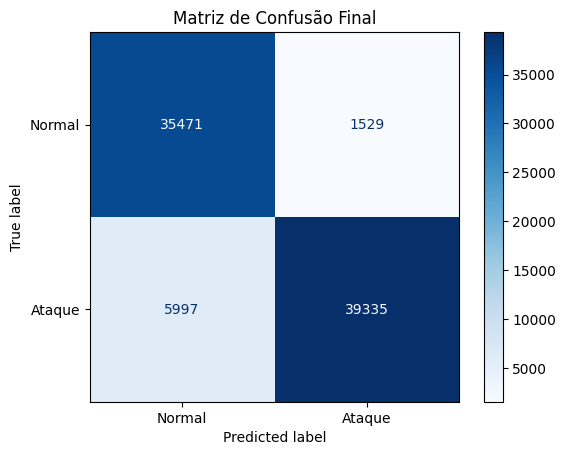

In [5]:
# Aplicar o threshold otimizado para gerar as predições finais
preds_finais = (probs >= best_threshold).astype(int)

print("\n--- MÉTRICAS TÉCNICAS (THRESHOLD OTIMIZADO) ---")
print(classification_report(y_test, preds_finais, target_names=['Normal', 'Ataque']))

# Matriz de Confusão
cm = confusion_matrix(y_test, preds_finais)
ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Ataque']).plot(cmap='Blues')
plt.title('Matriz de Confusão Final')
plt.show()

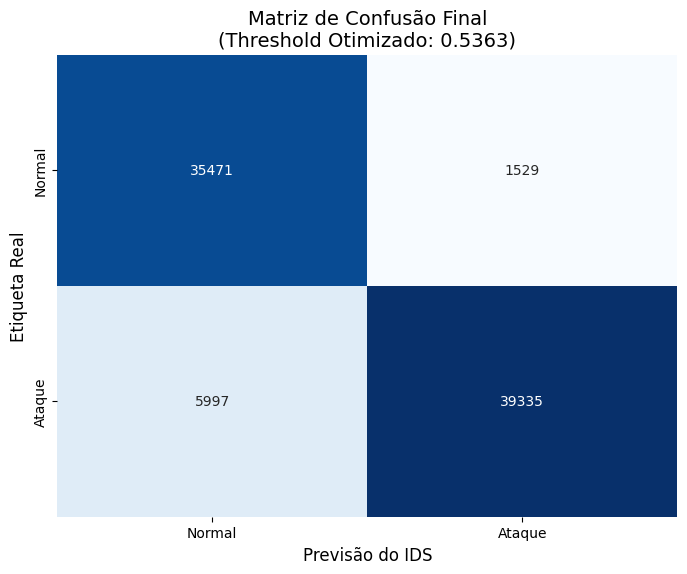

📊 Taxa de Alarme Falso (FPR): 4.1324%
📊 Taxa de Detecção (Recall): 86.7709%


In [6]:
# 1. Gerar a matriz
cm = confusion_matrix(y_test, preds_finais)

# 2. Plotar com Seaborn para um visual mais limpo
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal', 'Ataque'], 
            yticklabels=['Normal', 'Ataque'])

plt.title(f'Matriz de Confusão Final\n(Threshold Otimizado: {best_threshold:.4f})', fontsize=14)
plt.ylabel('Etiqueta Real', fontsize=12)
plt.xlabel('Previsão do IDS', fontsize=12)
plt.show()

# Cálculo de métricas específicas de segurança
tn, fp, fn, tp = cm.ravel()
fpr_final = fp / (fp + tn)
print(f"📊 Taxa de Alarme Falso (FPR): {fpr_final:.4%}")
print(f"📊 Taxa de Detecção (Recall): {tp / (tp + fn):.4%}")

In [7]:
def generate_fgsm_attack(model, x, y, epsilon):
    x_adv = x.clone().detach().requires_grad_(True)
    outputs = model(x_adv)
    # Se a saída for [N, 1], usamos binary_cross_entropy_with_logits
    loss = F.binary_cross_entropy_with_logits(outputs.squeeze(), y.float())
    model.zero_grad()
    loss.backward()
    
    # Criar a perturbação baseada no sinal do gradiente
    x_adv = x_adv + epsilon * x_adv.grad.sign()
    return x_adv.detach()

# 1. Preparar os dados para o PyTorch (usando apenas a parte de ataque do test set)
# Vamos testar a robustez apenas nas amostras que são realmente ataques
idx_ataque = np.where(y_test == 1)[0]
Z_ataque_t = torch.FloatTensor(Z_test[idx_ataque]).to(device)
y_ataque_t = torch.FloatTensor(y_test[idx_ataque]).to(device)

# 2. Gerar o ataque (Epsilon 0.05 é uma perturbação pequena mas comum)
model_pt = modelo_final.estimator.model_pytorch # Aceder ao modelo interno
Z_adv = generate_fgsm_attack(model_pt, Z_ataque_t, y_ataque_t, epsilon=0.05)

# 3. Avaliar o modelo contra os dados manipulados
with torch.no_grad():
    logits_adv = model_pt(Z_adv)
    probs_adv = torch.sigmoid(logits_adv).cpu().numpy()
    # Usamos o mesmo threshold otimizado de antes!
    preds_adv = (probs_adv >= best_threshold).astype(int)

recall_sob_ataque = np.mean(preds_adv)
print(f"🛑 Recall Original: {0.87:.4f}")
print(f"💥 Recall Sob Ataque Adversarial (FGSM): {recall_sob_ataque:.4f}")
print(f"📉 Queda na detecção: {(0.87 - recall_sob_ataque)*100:.2f}%")

🛑 Recall Original: 0.8700
💥 Recall Sob Ataque Adversarial (FGSM): 0.8298
📉 Queda na detecção: 4.02%
